In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def calculate_specific_humidity(temperature_celsius, relative_humidity_percent, atmospheric_pressure_hpa):
    """
    Calculates specific humidity from temperature, relative humidity, and atmospheric pressure.

    Args:
        temperature_celsius (float): Temperature in degrees Celsius.
        relative_humidity_percent (float): Relative humidity as a percentage (e.g., 75 for 75%).
        atmospheric_pressure_hpa (float): Atmospheric pressure in hectopascals (hPa).

    Returns:
        float: Specific humidity in kg/kg.
    """

    # 1. Calculate the Saturation Vapor Pressure (Ps) using the Magnus-Tetens formula.
    ps = 6.112 * np.exp((17.62 * temperature_celsius) / (243.12 + temperature_celsius))

    # 2. Calculate the Actual Vapor Pressure (Pv) from relative humidity.
    pv = ps * (relative_humidity_percent / 100)

    # 3. Calculate the Specific Humidity (q) using the atmospheric pressure and actual vapor pressure.
    # The constant 0.622 is the ratio of the molecular weight of water vapor to dry air.
    q = (0.622 * pv) / (atmospheric_pressure_hpa - pv)

    return q

In [ ]:

atto_raw_file = '/Net/Groups/BSI/work_scratch/ppapastefanou/atto_summerschool_25/data/ATTO_data_30min_model_input_evaluation_v2_2014-2023.csv'
df_atto_raw = pd.read_csv(atto_raw_file)
df_atto_raw['datetime'] = pd.to_datetime(df_atto_raw['datetime'])
df_atto_raw.set_index('datetime', inplace=True)
df_atto_raw['Year'] = df_atto_raw.index.year
df_atto_raw['Month'] = df_atto_raw.index.month
df_atto_raw['Day_of_year'] = df_atto_raw.index.dayofyear
df_atto_raw['Hour'] = df_atto_raw.index.hour
df_atto_raw['Minute'] = df_atto_raw.index.minute
df_atto_raw['q_36m'] = calculate_specific_humidity(df_atto_raw['Tair_36m'],df_atto_raw['RH_36m'] , df_atto_raw['AP_36m_kPa']*10 )
df_atto_raw['Rainfall'] = df_atto_raw['Rainfall'].fillna(0.0)
#Atto does not have duplicate years
#df_atto_raw = df_atto_raw[~df_atto_raw.index.duplicated(keep="first")]


/tmp/ipykernel_1538919/665520216.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_atto_raw = pd.read_csv(atto_raw_file)


,SW_in_81m (W/m2),SW_in_81m (W/m2)_ID,SW_in_ERA5 (W/m2),SW_in_GF (W/m2),SW_in_GF_ID,NEE_U50_orig,NEE_U50_f,NEE_U50_fnum,Tair_55m,Tair_55m_ID,...,Flux_Tsonic,Flux_Op-H2O,Qf_F_Tsonic,Qf_F_Op-H2O,Year,Month,Day_of_year,Hour,Minute,q_36m
datetime,,,,,,,,,,,,,,,,,,,,,
2014-01-01 01:30:00,0.000000,NaN,0.000000,0.000000,Obs,6.8484,6.8484,4.0,24.914667,Obs,...,NaN,NaN,4.0,4.0,2014,1,1,1,30,0.018128
2014-01-01 09:30:00,642.930000,NaN,542.643611,642.930000,Obs,-16.0950,-16.0950,3.0,27.406000,Obs,...,NaN,NaN,2.0,4.0,2014,1,1,9,30,0.019518
2014-01-01 10:30:00,901.370000,NaN,687.037222,901.370000,Obs,-18.6260,-18.6260,8.0,28.843333,Obs,...,NaN,NaN,2.0,2.0,2014,1,1,10,30,0.018971
2014-01-01 11:00:00,825.180000,NaN,698.018194,825.180000,Obs,-16.0600,-16.0600,14.0,29.339333,Obs,...,NaN,NaN,2.0,1.0,2014,1,1,11,0,0.019164
2014-01-01 11:30:00,685.550000,NaN,708.999167,685.550000,Obs,-11.2430,-11.2430,9.0,29.381333,Obs,...,NaN,NaN,2.0,2.0,2014,1,1,11,30,0.018806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 14:30:00,44.198333,Obs,421.711667,44.198333,Obs,4.4752,4.4752,29.0,23.474667,Obs,...,NaN,NaN,2.0,2.0,2023,12,365,14,30,0.018766
2023-12-31 15:00:00,34.072333,Obs,372.214444,34.072333,Obs,3.5580,3.5580,25.0,23.560667,Obs,...,NaN,NaN,2.0,1.0,2023,12,365,15,0,0.018909
2023-12-31 16:00:00,62.389000,Obs,265.714167,62.389000,Obs,5.4575,5.4575,20.0,23.573667,Obs,...,NaN,NaN,2.0,2.0,2023,12,365,16,0,0.018910


In [6]:
df_atto_raw['Day_of_year'].describe()

count    175287.000000
mean        183.090880
std         105.419093
min           1.000000
25%          92.000000
50%         183.000000
75%         274.000000
max         366.000000
Name: Day_of_year, dtype: float64

In [26]:
is_leap = df_atto_raw.index.is_leap_year

# New adjusted column
df_atto_raw["day_of_year_adj"] = df_atto_raw["Day_of_year"]

# Mark Feb 29 as NaN (or could drop later)
#df_atto_raw.loc[(is_leap) & (df_atto_raw.index.month == 2) & (df_atto_raw.index.day == 29), "day_of_year_adj"] = None

# Shift days after Feb 29
df_atto_raw.loc[(is_leap) & (df_atto_raw["Day_of_year"] > 60), "day_of_year_adj"] -= 1

df_atto_raw["day_of_year_adj"]= df_atto_raw["day_of_year_adj"].astype(int)

df_NEE = df_atto_raw.dropna(subset=['NEE_U50_orig'])
df_nee_export = df_NEE[['Year', 'Month', 'Hour', 'Minute',
       'day_of_year_adj','NEE_U50_orig']]
df_nee_export.to_csv("../data/ATTO_evaluation.csv")


#df_atto_raw



In [4]:
df_zf2 = pd.read_csv("../data/BR-Ma2/AMF_BR-Ma2_BASE_HH_1-5.csv", delimiter = ',', skiprows=2)
df_zf2['datetime'] = pd.to_datetime(df_zf2['TIMESTAMP_START'], format='%Y%m%d%H%M')
df_zf2.set_index('datetime', inplace=True)
df_zf2 = df_zf2.replace(-9999.0, np.nan)
df_zf2['Year'] = df_zf2.index.year
df_zf2['Month'] = df_zf2.index.month
df_zf2['Day_of_year'] = df_zf2.index.dayofyear
df_zf2['Q'] = calculate_specific_humidity(df_zf2['TA'],df_zf2['RH'] , df_zf2['PA']*10)
#df_zf2['P'] = df_zf2['P'].fillna(0.0)
df_zf2.columns

Index(['TIMESTAMP_START', 'TIMESTAMP_END', 'FC', 'LE', 'H', 'SW_IN', 'TA',
       'RH', 'USTAR', 'CO2_1_1_1', 'CO2_1_2_1', 'CO2_1_3_1', 'CO2_1_4_1',
       'CO2_1_5_1', 'CO2_1_6_1', 'PA', 'SW_OUT', 'LW_IN', 'LW_OUT', 'NETRAD',
       'PPFD_IN', 'P', 'WS', 'WD', 'SC_PI_F', 'NEE_PI_F', 'VPD_PI_F',
       'TA_PI_F', 'SW_IN_PI_F', 'P_PI_F', 'LE_PI_F', 'H_PI_F', 'RECO_PI_F',
       'GPP_PI_F', 'Year', 'Month', 'Day_of_year', 'Q'],
      dtype='object')

In [26]:
vars_atto = ["Tair_36m", "q_36m", "LW_atm_calc", 'SW_in_GF (W/m2)',  'AP_36m_kPa','WSp_50m']
noise_levels_atto = [[-0.2, 0.6], [-0.4,1.5],[-0.8, 0.8], [-0.5, 0.5], [-0.5, 0.5],[-0.5, 0.5]]

vars_zf2 = ["TA", "Q", "LW_IN", 'SW_IN_PI_F',  'PA', 'WS']
noise_levels_zf2 = [[-0.2, 0.6], [-0.4,1.5],[-0.8, 0.8], [-0.5, 0.5], [-0.5, 0.5],[-0.5, 0.5]]

In [27]:
# length of before/after anchors in days
anchor_days = 30     

def fill_gap(variable, dataframe, noise_level):
    if dataframe[variable].notna().sum() == dataframe.shape[0]:
        print("Contains no nan. No gapfilling needed")       
    
        df_filled = pd.DataFrame({
            variable: dataframe[variable],
            f"{variable}_flag": 0,
            f"{variable}_filled": dataframe[variable]
        })            
        return df_filled   

    else:
        # === 1. Original series ===
        se = dataframe[variable]  # Series
        freq = (se.index[1] - se.index[0])  # timedelta for frequency
        anchor_points = int(anchor_days * 24 * 60 / (freq.seconds / 60))  # convert days -> number of points

        # === 2. Seasonal mean (day-of-year) ===
        seasonal_cycle = se.groupby(se.index.dayofyear).mean()

        # === 3. Deseasonalize to get daily cycle ===
        deseasonalized = se - se.index.dayofyear.map(seasonal_cycle)
        daily_cycle = deseasonalized.groupby([se.index.hour, se.index.minute]).mean()

        # === 4. Compute expected mean values ===
        expected = pd.Series(
            seasonal_cycle[se.index.dayofyear].values +
            se.index.to_series().map(lambda ts: daily_cycle.loc[(ts.hour, ts.minute)]).values,
            index=se.index
        )

        # === 5. Identify missing values ===
        filled_flag = se.isna().astype(int)

        # === 6. Initial fill with seasonal+daily mean ===
        filled_series = se.copy()
        filled_series[filled_flag == 1] = expected[filled_flag == 1]

        # === 7. Smooth long gaps with quantile-based ramping ===
        mask = filled_flag == 1
        gap_groups = (mask != mask.shift()).cumsum()
        gaps = filled_series[mask].groupby(gap_groups[mask])

        for _, gap in gaps:
            start_idx = gap.index[0]
            end_idx = gap.index[-1]
            
            # Anchor indices (before and after gap)
            start_anchor_idx = max(se.index.get_loc(start_idx) - anchor_points, 0)
            end_anchor_idx = min(se.index.get_loc(end_idx) + anchor_points + 1, len(se))
            
            # Start/end anchor data
            start_anchor_data = filled_series.iloc[start_anchor_idx:se.index.get_loc(start_idx)]
            end_anchor_data = filled_series.iloc[se.index.get_loc(end_idx)+1:end_anchor_idx]
            
            # Median for central tendency
            start_median = start_anchor_data.quantile(0.5)
            end_median = end_anchor_data.quantile(0.5)
            
            # IQR for variability
            start_iqr = start_anchor_data.quantile(0.75) - start_anchor_data.quantile(0.25)
            end_iqr = end_anchor_data.quantile(0.75) - end_anchor_data.quantile(0.25)
            
            # Linear ramp
            n_gap = len(gap)
            alpha = np.linspace(0, 1, n_gap)
            
            ramp_median = (1 - alpha) * start_median + alpha * end_median
            ramp_iqr = (1 - alpha) * start_iqr + alpha * end_iqr
            
            # Apply ramp: seasonal+daily mean + scaled variability (IQR)
            gap_mean = expected[gap.index].values
            filled_series.iloc[se.index.get_loc(start_idx):se.index.get_loc(end_idx)+1] = gap_mean +  \
                np.random.uniform(noise_level[0], noise_level[1], size=n_gap) * ramp_iqr

        # === 8. Combine into DataFrame ===
        df_filled = pd.DataFrame({
            variable: se,
            f"{variable}_flag": filled_flag,
            f"{variable}_filled": filled_series
        })
        return df_filled


In [28]:
#df_filled = fill_gap(vars_atto[0], df_atto_raw, noise_levels_atto[0])
df_filled = fill_gap(vars_zf2[3], df_zf2, noise_levels_zf2[3])

In [24]:
df_filled

,SW_IN_PI_F,SW_IN_PI_F_flag,SW_IN_PI_F_filled
datetime,,,
1999-01-01 00:00:00,NaN,1,NaN
1999-01-01 00:30:00,NaN,1,NaN
1999-01-01 01:00:00,NaN,1,NaN
1999-01-01 01:30:00,NaN,1,NaN
1999-01-01 02:00:00,NaN,1,NaN
...,...,...,...
2016-12-31 21:30:00,0.0,0,0.0
2016-12-31 22:00:00,0.0,0,0.0
2016-12-31 22:30:00,0.0,0,0.0


In [29]:
    
def gen_plot(df_input, varname):
    
    dfs = df_input
    dfs['Year'] = dfs.index.year
    dfs['Month'] = dfs.index.month
    dfs['Day_of_year'] = dfs.index.dayofyear
    
    
    fig, ax = plt.subplots(3, 2, figsize=(12,8))
    
    cols = ['green', 'blue', 'orange']
    variants = ['org', 'filled only', 'org + filled']
    

    for i in [0,1,2]:
        if i == 2:
            df = dfs
        else:
            df = dfs[dfs[f"{varname}_flag"] == i]


        varnamef = f'{varname}_filled'

        ax[0,0].plot(df[varnamef], alpha = 0.6, c= cols[i])
        ax[0,0].set_ylabel(varnamef)
        
        df_zf2_grp = df.groupby(['Year', 'Month'])[varnamef].mean().reset_index()
        df_zf2_grp['Period'] = pd.to_datetime(
            df_zf2_grp['Year'].astype(str) + '-' + df_zf2_grp['Month'].astype(str) + '-01'
        )
        df_zf2_grp.set_index(df_zf2_grp['Period'], inplace=True)


        ax[1,0].plot(df_zf2_grp[varnamef], alpha = 0.6, c= cols[i])
        ax[1,0].set_ylabel(varnamef)

        df_zf2_grp = df.groupby(['Year'])[varnamef].mean().reset_index()
        df_zf2_grp['Period'] = pd.to_datetime(
            df_zf2_grp['Year'].astype(str) + '-01-01'
        )
        df_zf2_grp.set_index(df_zf2_grp['Period'], inplace=True)
        ax[2,0].plot(df_zf2_grp[varnamef], alpha = 0.6, c= cols[i], label= variants[i])
        ax[2,0].set_ylabel(varnamef)
        ax[2,0].legend()

        df_zf2_grp = df.groupby(['Day_of_year'])[varnamef].mean().reset_index()

        ax[0,1].plot(df_zf2_grp[varnamef], alpha = 0.6, c= cols[i])
        ax[1,1].set_xlabel("Average Year")
        
        df_zf2_grp = df.groupby(pd.Grouper(freq='30T'))[varnamef].mean()
        df_zf2_grp = pd.DataFrame(df_zf2_grp.groupby(df_zf2_grp.index.time).mean())

        ax[1,1].plot(np.arange(0,24, 0.5),df_zf2_grp[varnamef].values, alpha = 0.6, c= cols[i])
        ax[1,1].set_ylabel(varnamef)
        ax[1,1].set_xlabel("Average Day")

    plt.subplots_adjust(hspace= 0.3)
    plt.show()
    #plt.savefig(f"{vnameZf}.png", dpi =300);

/tmp/ipykernel_298400/1315394715.py:51: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_zf2_grp = df.groupby(pd.Grouper(freq='30T'))[varnamef].mean()
/tmp/ipykernel_298400/1315394715.py:51: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_zf2_grp = df.groupby(pd.Grouper(freq='30T'))[varnamef].mean()
/tmp/ipykernel_298400/1315394715.py:51: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_zf2_grp = df.groupby(pd.Grouper(freq='30T'))[varnamef].mean()


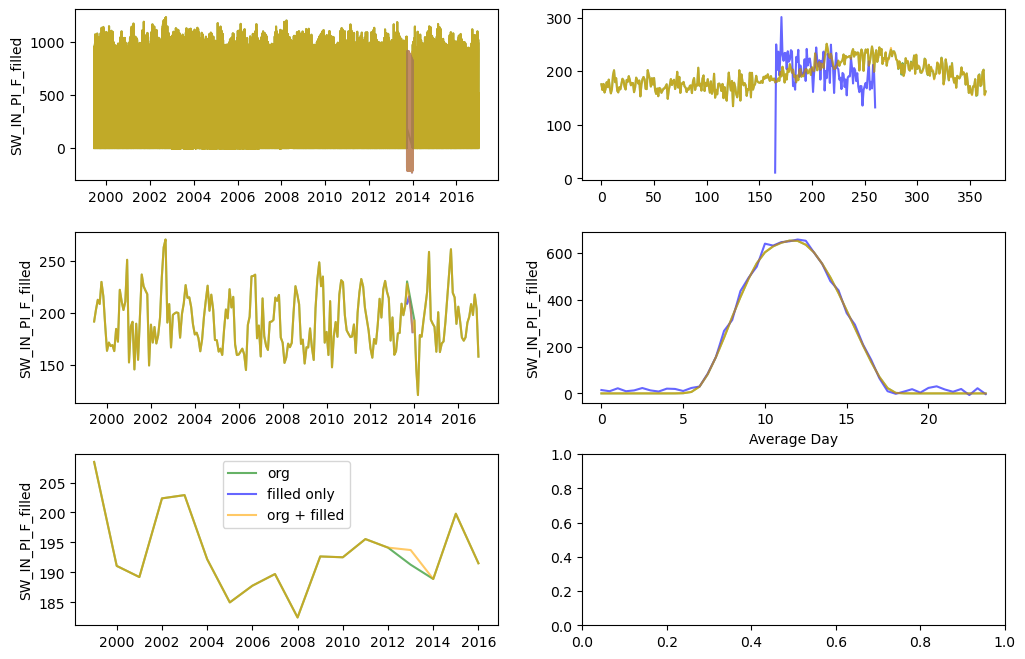

In [30]:
gen_plot(df_filled,vars_zf2[3])

In [31]:
# Zf2 precipitation deserves some special attention...

# Identify where NaNs are
mask = df_zf2['P'].isna()


if df_zf2['P'].notna().sum() == df_zf2.shape[0]:
    print("Contains no nan. No gapfilling needed")    

else:
    # Find start and end points of NaN sequences
    nan_groups = (mask != mask.shift()).cumsum()  # group consecutive values
    nan_spans = (
        df_zf2[mask]
        .groupby(nan_groups[mask])
        .apply(lambda g: pd.Series({
            "start": g.index[0],
            "end": g.index[-1],
            "duration": g.index[-1] - g.index[0]
        }))
    ).reset_index(drop=True)
nan_spans.sort_values(by='duration', ascending=False)

,start,end,duration
0,1999-01-01 00:00:00,1999-06-15 08:00:00,165 days 08:00:00
88,2012-12-27 12:00:00,2013-05-31 13:00:00,155 days 01:00:00
93,2013-10-18 02:30:00,2013-11-26 13:00:00,39 days 10:30:00
28,2005-01-08 08:00:00,2005-02-14 09:30:00,37 days 01:30:00
154,2015-03-08 16:00:00,2015-04-09 13:30:00,31 days 21:30:00
...,...,...,...
156,2015-06-24 15:30:00,2015-06-24 15:30:00,0 days 00:00:00
157,2015-07-04 12:30:00,2015-07-04 12:30:00,0 days 00:00:00
8,2001-07-04 11:00:00,2001-07-04 11:00:00,0 days 00:00:00
162,2015-08-20 08:30:00,2015-08-20 08:30:00,0 days 00:00:00


In [32]:
dates_this = pd.date_range("2012-12-01", "2013-06-01", freq="30min")
dates_prev = pd.date_range("2011-12-01", "2012-06-01", freq="30min")
for d_this, d_prev in zip(dates_this, dates_prev):
    if d_this in df_zf2.index and d_prev in df_zf2.index:
        df_zf2.loc[d_this, 'P'] = df_zf2.loc[d_prev, 'P']
        
        
dates_this = pd.date_range("2013-10-18", "2013-11-26", freq="30min")
dates_prev = pd.date_range("2012-10-18", "2012-11-26", freq="30min")
for d_this, d_prev in zip(dates_this, dates_prev):
    if d_this in df_zf2.index and d_prev in df_zf2.index:
        df_zf2.loc[d_this, 'P'] = df_zf2.loc[d_prev, 'P']
        

In [213]:

datats = {
    'start': [
       '2005-01-08 08:00', '2015-03-08 16:00',
        '2000-11-30 16:30', '2005-02-26 06:00', '2014-02-26 17:00',
        '2002-05-27 14:00', '2000-02-06 20:00', '2009-09-19 14:00', '2010-04-10 18:30', 
    ],
    'end': [
     '2005-02-14 09:30', '2015-04-09 13:00',
        '2000-12-31 23:30', '2005-03-26 01:00', '2014-03-25 13:00',
        '2002-06-16 16:30', '2000-10-06 16:30', '2000-10-11 12:30', '2010-05-01 11:00',
    ]
}

df = pd.DataFrame(datats)
df['start'] = pd.to_datetime(df['start'])
df['end'] = pd.to_datetime(df['end'])


for start, end in zip(df['start'], df['end']):    
                
    if start.year == 2000:
        offset = 1
    else:
        offset = -1
    dates_this = pd.date_range(start, end, freq="30min")
    dates_prev = pd.date_range(start +pd.DateOffset(years=offset), end + pd.DateOffset(years=offset), freq="30min")
    #print(dates_this)
    for d_this, d_prev in zip(dates_this, dates_prev):
        if d_this in df_zf2.index and d_prev in df_zf2.index:
            df_zf2.loc[d_this, 'P'] = df_zf2.loc[d_prev, 'P']


# dates_this = pd.date_range("2012-12-01", "2013-06-01")
# dates_prev = pd.date_range("2011-12-01", "2012-06-01")
# for d_this, d_prev in zip(dates_this, dates_prev):
#     if d_this in df_zf2.index and d_prev in df_zf2.index:
#         df_zf2.loc[d_this, 'P'] = df_zf2.loc[d_prev, 'P']
        
        
# dates_this = pd.date_range("2013-10-18", "2013-11-26")
# dates_prev = pd.date_range("2012-10-18", "2012-11-26")
# for d_this, d_prev in zip(dates_this, dates_prev):
#     if d_this in df_zf2.index and d_prev in df_zf2.index:
#         df_zf2.loc[d_this, 'P'] = df_zf2.loc[d_prev, 'P']

In [33]:
# Identify where NaNs are
mask = df_zf2['P'].isna()

if df_zf2['P'].notna().sum() == df_zf2.shape[0]:
    print("Contains no nan. No gapfilling needed")    

else:
    # Find start and end points of NaN sequences
    nan_groups = (mask != mask.shift()).cumsum()  # group consecutive values
    nan_spans = (
        df_zf2[mask]
        .groupby(nan_groups[mask])
        .apply(lambda g: pd.Series({
            "start": g.index[0],
            "end": g.index[-1],
            "duration": g.index[-1] - g.index[0]
        }))
    ).reset_index(drop=True)
nan_spans.sort_values(by='duration', ascending=False)

,start,end,duration
0,1999-01-01 00:00:00,1999-06-15 08:00:00,165 days 08:00:00
28,2005-01-08 08:00:00,2005-02-14 09:30:00,37 days 01:30:00
169,2015-03-08 16:00:00,2015-04-09 13:30:00,31 days 21:30:00
5,2000-11-30 16:30:00,2000-12-31 23:30:00,31 days 07:00:00
30,2005-02-26 06:00:00,2005-03-26 01:00:00,27 days 19:00:00
...,...,...,...
168,2014-12-20 00:30:00,2014-12-20 00:30:00,0 days 00:00:00
171,2015-06-24 15:30:00,2015-06-24 15:30:00,0 days 00:00:00
172,2015-07-04 12:30:00,2015-07-04 12:30:00,0 days 00:00:00
173,2015-07-21 14:00:00,2015-07-21 14:00:00,0 days 00:00:00


In [34]:
df_zf2['P'] = df_zf2['P'].fillna(0.0)

In [35]:
# Identify where NaNs are
mask = df_zf2['P'].isna()

if df_zf2['P'].notna().sum() == df_zf2.shape[0]:
    print("Contains no nan. No gapfilling needed")    

else:
    # Find start and end points of NaN sequences
    nan_groups = (mask != mask.shift()).cumsum()  # group consecutive values
    nan_spans = (
        df_zf2[mask]
        .groupby(nan_groups[mask])
        .apply(lambda g: pd.Series({
            "start": g.index[0],
            "end": g.index[-1],
            "duration": g.index[-1] - g.index[0]
        }))
    ).reset_index(drop=True)
    nan_spans.sort_values(by='duration', ascending=False)

Contains no nan. No gapfilling needed


In [36]:
for id in range(0, 6):
    variable = vars_zf2[id]

    df_filled = fill_gap(variable, df_zf2, noise_levels_zf2[id])

    if id== 0:
        dfh = df_filled[[variable, f"{variable}_flag", f"{variable}_filled"]]
    else:
        dfh=  pd.concat([dfh,df_filled[[variable, f"{variable}_flag", f"{variable}_filled"]] ], axis = 1)
dfh['P'] = df_zf2['P']

In [37]:
dfh.to_csv("../data/BR-Ma2/ZF2_gapfilled.csv")

In [145]:
dfh

,TA,TA_flag,TA_filled,Q,Q_flag,Q_filled,LW_IN,LW_IN_flag,LW_IN_filled,SW_IN_PI_F,SW_IN_PI_F_flag,SW_IN_PI_F_filled,PA,PA_flag,PA_filled,WS,WS_flag,WS_filled,P
datetime,,,,,,,,,,,,,,,,,,,
1999-01-01 00:00:00,NaN,1,NaN,NaN,1,NaN,NaN,1,NaN,NaN,1,NaN,NaN,1,NaN,NaN,1,NaN,0.0
1999-01-01 00:30:00,NaN,1,NaN,NaN,1,NaN,NaN,1,NaN,NaN,1,NaN,NaN,1,NaN,NaN,1,NaN,0.0
1999-01-01 01:00:00,NaN,1,NaN,NaN,1,NaN,NaN,1,NaN,NaN,1,NaN,NaN,1,NaN,NaN,1,NaN,0.0
1999-01-01 01:30:00,NaN,1,NaN,NaN,1,NaN,NaN,1,NaN,NaN,1,NaN,NaN,1,NaN,NaN,1,NaN,0.0
1999-01-01 02:00:00,NaN,1,NaN,NaN,1,NaN,NaN,1,NaN,NaN,1,NaN,NaN,1,NaN,NaN,1,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-31 21:30:00,24.12,0,24.12,0.018492,0,0.018492,423.06,0,423.06,0.0,0,0.0,99.691,0,99.691,1.132,0,1.132,0.0
2016-12-31 22:00:00,24.03,0,24.03,0.018503,0,0.018503,424.76,0,424.76,0.0,0,0.0,99.716,0,99.716,1.148,0,1.148,0.0
2016-12-31 22:30:00,24.11,0,24.11,0.018457,0,0.018457,428.40,0,428.40,0.0,0,0.0,99.709,0,99.709,1.505,0,1.505,0.0


In [153]:
for id in range(0, 6):
    variable = vars_atto[id]
    print(variable)
    df_filled = fill_gap(variable, df_atto_raw, noise_levels_atto[id])

    if id== 0:
        dfh = df_filled[[variable, f"{variable}_flag", f"{variable}_filled"]]
    else:
        dfh=  pd.concat([dfh, df_filled[[variable, f"{variable}_flag", f"{variable}_filled"]] ], axis = 1)
dfh['Rainfall'] = df_atto_raw['Rainfall'].fillna(0.0)
dfh.to_csv("../data/ATTO_gapfilled.csv")

Tair_36m
q_36m
LW_atm_calc
SW_in_GF (W/m2)
Contains no nan. No gapfilling needed
AP_36m_kPa
Contains no nan. No gapfilling needed
WSp_50m
